In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
dataset_path=r"C:\Users\Lohith\Desktop\Task-04\dataset\leapGestRecog"
print(os.listdir(dataset_path))

['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']


In [4]:
for folder in sorted(os.listdir(dataset_path)):
    folder_path=os.path.join(dataset_path,folder)

    if os.path.isdir(folder_path):
        image_count=len(os.listdir(folder_path))
        print(f"{folder}:{image_count} files")

00:10 files
01:10 files
02:10 files
03:10 files
04:10 files
05:10 files
06:10 files
07:10 files
08:10 files
09:10 files


In [5]:
folder_00 = os.path.join(dataset_path, "00")

print(os.listdir(folder_00))

['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


In [6]:
folder_00 = os.path.join(dataset_path, "00")

for item in os.listdir(folder_00):
    item_path = os.path.join(folder_00, item)
    
    if os.path.isdir(item_path):
        print(item)

01_palm
02_l
03_fist
04_fist_moved
05_thumb
06_index
07_ok
08_palm_moved
09_c
10_down


In [7]:
total_images = 0

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            total_images += 1

print("Total images:", total_images)

Total images: 20000


In [8]:
from collections import Counter

gesture_counts = Counter()

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            gesture_name = os.path.basename(root)
            gesture_counts[gesture_name] += 1

for gesture, count in sorted(gesture_counts.items()):
    print(f"{gesture}: {count}")

01_palm: 2000
02_l: 2000
03_fist: 2000
04_fist_moved: 2000
05_thumb: 2000
06_index: 2000
07_ok: 2000
08_palm_moved: 2000
09_c: 2000
10_down: 2000


Image size: (640, 240)
Image mode: L


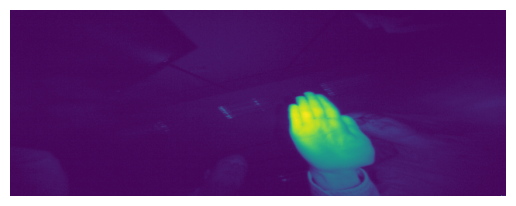

In [9]:
from PIL import Image
image_path=os.path.join(
    dataset_path,
    "00",
    "01_palm",
    os.listdir(os.path.join(dataset_path,"00","01_palm"))[0]
)

image=Image.open(image_path)
print("Image size:",image.size)
print("Image mode:",image.mode)
plt.imshow(image)
plt.axis("off")
plt.show()

In [10]:
from PIL import Image
image=Image.open(image_path)
resized_image=image.resize((128,128))

print("Original size:",image.size)
print("Resized size:",resized_image.size)

Original size: (640, 240)
Resized size: (128, 128)


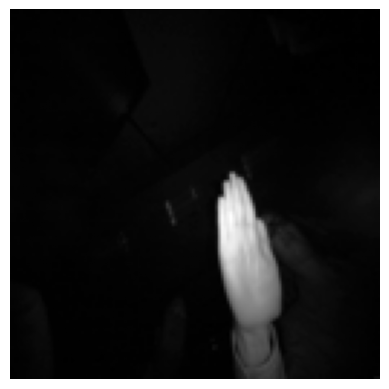

In [11]:
import matplotlib.pyplot as plt
plt.imshow(resized_image,cmap="gray")
plt.axis("off")
plt.show()

In [12]:
import numpy as np
image_array=np.array(resized_image)

print(image_array.shape)
print(image_array.dtype)

(128, 128)
uint8


In [13]:
normalized_image=image_array/255.0
print(normalized_image.min())
print(normalized_image.max())
print(normalized_image.shape)



0.011764705882352941
0.8941176470588236
(128, 128)


In [14]:
normalized_image=np.expand_dims(normalized_image,axis=-1)
print(normalized_image.shape)

(128, 128, 1)


In [15]:
class_names=[
    "01_palm",
    "02_l",
    "03_fist",
    "04_fist_moved",
    "05_thumb",
    "06_index",
    "07_ok",
    "08_palm_moved",
    "09_c",
    "10_down"
]
print(class_names)

['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


In [16]:
print(len(class_names))

10


In [17]:
for label,class_name in enumerate(class_names):
    print(label,class_name)

0 01_palm
1 02_l
2 03_fist
3 04_fist_moved
4 05_thumb
5 06_index
6 07_ok
7 08_palm_moved
8 09_c
9 10_down


In [24]:
print(dataset_path)
dataset_path=r"C:\Users\Lohith\Desktop\Task-04\dataset\leapGestRecog"
print(dataset_path)

C:\Users\Lohith\Desktop\Task-04\dataset\leapGestRecog\00
C:\Users\Lohith\Desktop\Task-04\dataset\leapGestRecog


In [26]:
images = []
labels = []

for person_folder in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person_folder)

    for label, class_name in enumerate(class_names):

        class_path = os.path.join(person_path, class_name)

        for file_name in os.listdir(class_path):

            image_path = os.path.join(class_path, file_name)

            image = Image.open(image_path)

            image = image.resize((128, 128))

            image_array = np.array(image)

            image_array = image_array / 255.0

            image_array = np.expand_dims(image_array, axis=-1)

            images.append(image_array)
            labels.append(label)

In [28]:
images=np.array(images)
labels=np.array(labels)
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: (20000, 128, 128, 1)
Labels shape: (20000,)


In [29]:
for label,class_name in enumerate(class_names):
    count=np.sum(labels==label)
    print(class_name,":",count)

01_palm : 2000
02_l : 2000
03_fist : 2000
04_fist_moved : 2000
05_thumb : 2000
06_index : 2000
07_ok : 2000
08_palm_moved : 2000
09_c : 2000
10_down : 2000


In [30]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [31]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (16000, 128, 128, 1)
X_test : (4000, 128, 128, 1)
y_train: (16000,)
y_test : (4000,)


In [34]:
for labels,class_name in enumerate(class_names):
    train_count=np.sum(y_train==label)
    test_count=np.sum(y_test==label)
    print(class_name,"->Train:",train_count,"Test:",test_count)

01_palm ->Train: 1600 Test: 400
02_l ->Train: 1600 Test: 400
03_fist ->Train: 1600 Test: 400
04_fist_moved ->Train: 1600 Test: 400
05_thumb ->Train: 1600 Test: 400
06_index ->Train: 1600 Test: 400
07_ok ->Train: 1600 Test: 400
08_palm_moved ->Train: 1600 Test: 400
09_c ->Train: 1600 Test: 400
10_down ->Train: 1600 Test: 400


In [40]:
import tensorflow as tf

model=tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(128,128,1)),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

c:\Users\Lohith\Desktop\Task-04\hand_gesture\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,034 (28.20 MB)

 Trainable params: 7,393,034 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(
    optimizer="Adam",
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [43]:
history=model.fit(
    X_train,y_train,epochs=10,batch_size=32,validation_split=0.2
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 54s 130ms/step - accuracy: 0.9346 - loss: 0.2188 - val_accuracy: 0.9941 - val_loss: 0.0189
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 55s 136ms/step - accuracy: 0.9989 - loss: 0.0051 - val_accuracy: 1.0000 - val_loss: 9.9014e-04
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 60s 150ms/step - accuracy: 0.9959 - loss: 0.0134 - val_accuracy: 0.9994 - val_loss: 0.0021
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 65s 161ms/step - accuracy: 0.9997 - loss: 8.5626e-04 - val_accuracy: 0.9997 - val_loss: 0.0011
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 65s 163ms/step - accuracy: 1.0000 - loss: 2.7215e-05 - val_accuracy: 0.9997 - val_loss: 7.9008e-04
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 65s 161ms/step - accuracy: 1.0000 - loss: 1.3994e-05 - val_accuracy: 0.9997 - val_loss: 6.9379e-04
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 65s 163ms/step - accuracy: 1.0000 - loss: 9.2867e-06 - val_accuracy: 0.9997 - val_loss: 6.4945e-04
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 66s 164ms/s

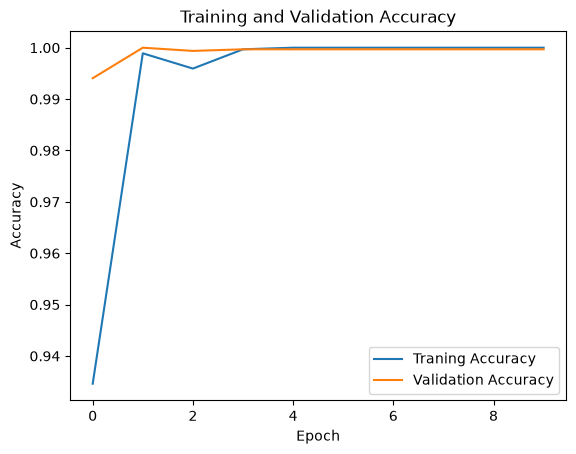

In [44]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"],label="Traning Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

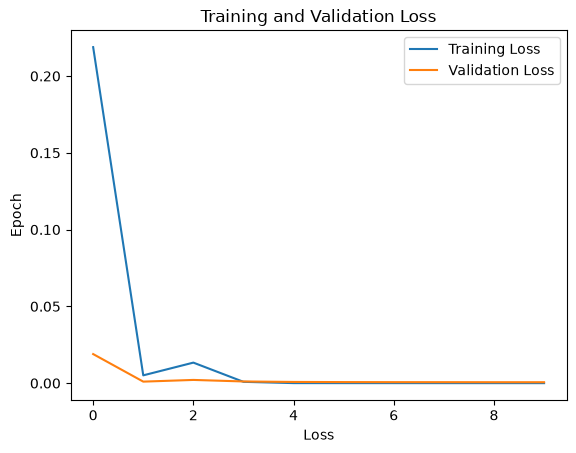

In [45]:
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")

plt.ylabel("Epoch")
plt.xlabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [46]:
model.evaluate(X_test,y_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 1.0000 - loss: 5.2521e-05


[5.2521430916385725e-05, 1.0]

In [48]:
y_pred=model.predict(X_test)
y_pred_classes=np.argmax(y_pred,axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


In [49]:
print(y_pred.shape)
print(y_pred_classes.shape)

(4000, 10)
(4000,)


In [50]:
for i in range(10):
    print(
        "Actual:",
        class_names[y_test[i]],
        "| Predicted:",
        class_names[y_pred_classes[i]]
    )

Actual: 07_ok | Predicted: 07_ok
Actual: 03_fist | Predicted: 03_fist
Actual: 06_index | Predicted: 06_index
Actual: 01_palm | Predicted: 01_palm
Actual: 10_down | Predicted: 10_down
Actual: 08_palm_moved | Predicted: 08_palm_moved
Actual: 04_fist_moved | Predicted: 04_fist_moved
Actual: 02_l | Predicted: 02_l
Actual: 07_ok | Predicted: 07_ok
Actual: 10_down | Predicted: 10_down


[[400   0   0   0   0   0   0   0   0   0]
 [  0 400   0   0   0   0   0   0   0   0]
 [  0   0 400   0   0   0   0   0   0   0]
 [  0   0   0 400   0   0   0   0   0   0]
 [  0   0   0   0 400   0   0   0   0   0]
 [  0   0   0   0   0 400   0   0   0   0]
 [  0   0   0   0   0   0 400   0   0   0]
 [  0   0   0   0   0   0   0 400   0   0]
 [  0   0   0   0   0   0   0   0 400   0]
 [  0   0   0   0   0   0   0   0   0 400]]


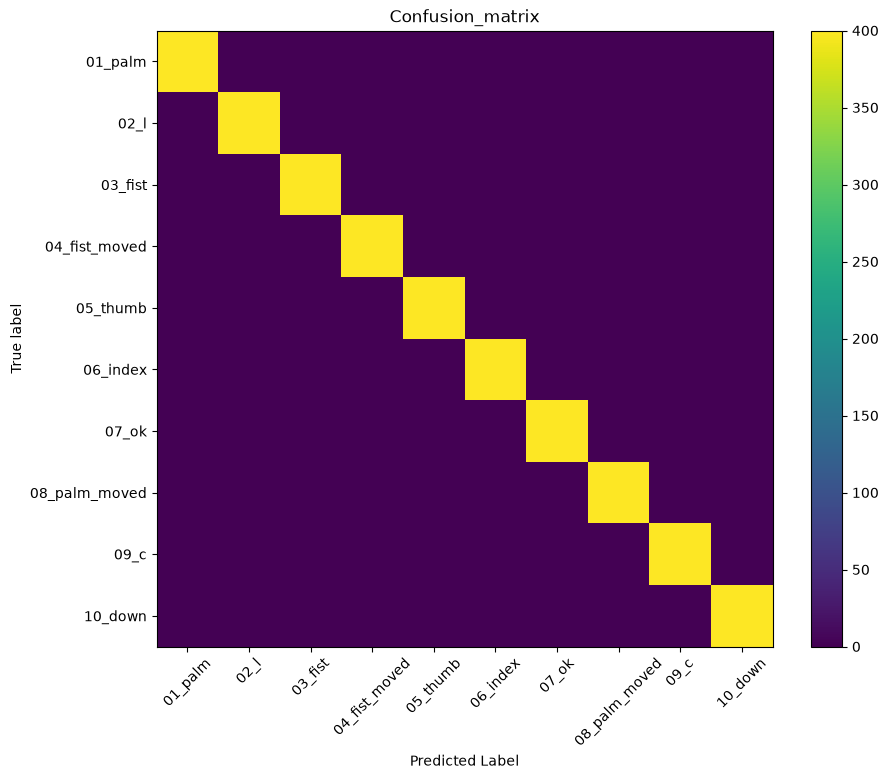

In [53]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred_classes)
print(cm)

plt.figure(figsize=(10,8))
plt.imshow(cm)
plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True label")
plt.title("Confusion_matrix")

plt.colorbar()
plt.show()

In [54]:
from sklearn.metrics import classification_report
report=classification_report(
    y_test,y_pred_classes,
    target_names=class_names
)
print(report)

               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       400
         02_l       1.00      1.00      1.00       400
      03_fist       1.00      1.00      1.00       400
04_fist_moved       1.00      1.00      1.00       400
     05_thumb       1.00      1.00      1.00       400
     06_index       1.00      1.00      1.00       400
        07_ok       1.00      1.00      1.00       400
08_palm_moved       1.00      1.00      1.00       400
         09_c       1.00      1.00      1.00       400
      10_down       1.00      1.00      1.00       400

     accuracy                           1.00      4000
    macro avg       1.00      1.00      1.00      4000
 weighted avg       1.00      1.00      1.00      4000



In [55]:
print("Image shape:", X_test[0].shape)
print("Actual label:", y_test[0])
print("Predicted label:", y_pred_classes[0])

Image shape: (128, 128, 1)
Actual label: 6
Predicted label: 6


In [56]:
image=X_test[0]
image_for_prediction=np.expand_dims(X_test[0],axis=0)
prediction=model.predict(image_for_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


In [ ]:
predicted_class=np.argmax(prediction[0])


np.int64(6)

In [60]:
confidence=np.max(prediction[0])

In [62]:
print("Actual:", class_names[y_test[0]])
print("Predicted:", class_names[predicted_class])
print("Confidence:", confidence * 100, "%")

Actual: 07_ok
Predicted: 07_ok
Confidence: 99.99987 %


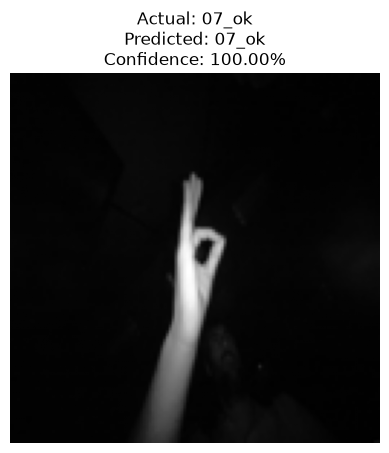

In [63]:
plt.imshow(X_test[0].squeeze(), cmap="gray")

plt.title(
    f"Actual: {class_names[y_test[0]]}\n"
    f"Predicted: {class_names[predicted_class]}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")
plt.show()

In [64]:
for i in range(10):
    
    prediction = model.predict(
        np.expand_dims(X_test[i], axis=0),
        verbose=0
    )
    
    predicted_class = np.argmax(prediction[0])
    
    confidence = np.max(prediction[0])
    
    print(
        f"Image {i+1}: "
        f"Actual = {class_names[y_test[i]]}, "
        f"Predicted = {class_names[predicted_class]}, "
        f"Confidence = {confidence * 100:.2f}%"
    )

Image 1: Actual = 07_ok, Predicted = 07_ok, Confidence = 100.00%
Image 2: Actual = 03_fist, Predicted = 03_fist, Confidence = 100.00%
Image 3: Actual = 06_index, Predicted = 06_index, Confidence = 100.00%
Image 4: Actual = 01_palm, Predicted = 01_palm, Confidence = 100.00%
Image 5: Actual = 10_down, Predicted = 10_down, Confidence = 100.00%
Image 6: Actual = 08_palm_moved, Predicted = 08_palm_moved, Confidence = 100.00%
Image 7: Actual = 04_fist_moved, Predicted = 04_fist_moved, Confidence = 100.00%
Image 8: Actual = 02_l, Predicted = 02_l, Confidence = 100.00%
Image 9: Actual = 07_ok, Predicted = 07_ok, Confidence = 100.00%
Image 10: Actual = 10_down, Predicted = 10_down, Confidence = 100.00%


In [65]:
model.save("hand_gesture_model.keras")

In [66]:
import os

print(os.path.exists("hand_gesture_model.keras"))

True


In [67]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

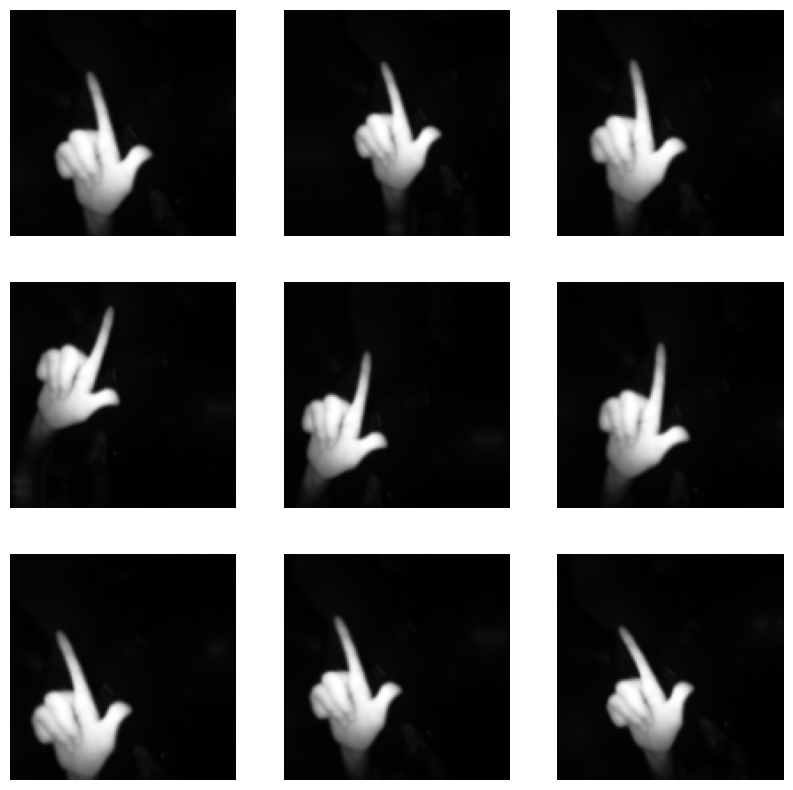

In [68]:
plt.figure(figsize=(10, 10))

for i in range(9):

    augmented_image = data_augmentation(
        np.expand_dims(X_train[0], axis=0),
        training=True
    )

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        augmented_image[0].numpy().squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.show()

In [69]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

model_v2 = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(128, 128, 1)),

    data_augmentation,

    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

In [70]:
model_v2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [71]:
model_v2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,034 (28.20 MB)

 Trainable params: 7,393,034 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
history_v2 = model_v2.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 139ms/step - accuracy: 0.6361 - loss: 1.0652 - val_accuracy: 0.7943 - val_loss: 0.6895
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 73s 145ms/step - accuracy: 0.8986 - loss: 0.3132 - val_accuracy: 0.9187 - val_loss: 0.2086
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 77s 154ms/step - accuracy: 0.9450 - loss: 0.1776 - val_accuracy: 0.9870 - val_loss: 0.0470
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 78s 156ms/step - accuracy: 0.9630 - loss: 0.1153 - val_accuracy: 0.9778 - val_loss: 0.0629
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 77s 155ms/step - accuracy: 0.9699 - loss: 0.0927 - val_accuracy: 0.9675 - val_loss: 0.1020
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 152ms/step - accuracy: 0.9774 - loss: 0.0786 - val_accuracy: 0.9877 - val_loss: 0.0433
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 77s 155ms/step - accuracy: 0.9785 - loss: 0.0692 - val_accuracy: 0.9405 - val_loss: 0.1759
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 160ms/step - accuracy: 0.9802 - loss: 0

In [73]:
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss_v2)
print("Test Accuracy:", test_accuracy_v2)

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9260 - loss: 0.2062
Test Loss: 0.20618389546871185
Test Accuracy: 0.9259999990463257


In [78]:
from PIL import Image
import numpy as np

image = Image.open(r"C:\Users\Lohith\Desktop\thumb-up-like-sign-hand-thumb.jpg")

In [79]:
image = image.convert("L")
image = image.resize((128, 128))

image_array = np.array(image)

image_array = image_array / 255.0

image_array = np.expand_dims(image_array, axis=-1)

image_array = np.expand_dims(image_array, axis=0)
print(image_array.shape)

(1, 128, 128, 1)


In [80]:
prediction_v2 = model_v2.predict(
    image_array,
    verbose=0
)

predicted_class_v2 = np.argmax(prediction_v2[0])

confidence_v2 = np.max(prediction_v2[0])

print("Predicted:", class_names[predicted_class_v2])
print("Confidence:", confidence_v2 * 100)

Predicted: 02_l
Confidence: 85.69874


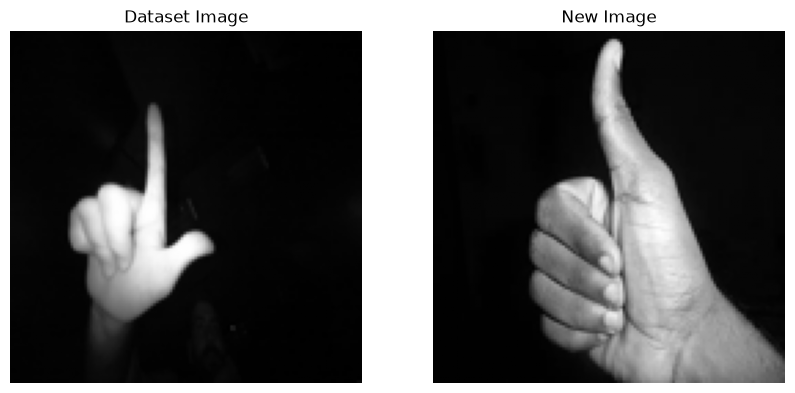

In [81]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(X_train[0].squeeze(), cmap="gray")
plt.title("Dataset Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_array[0].squeeze(), cmap="gray")
plt.title("New Image")
plt.axis("off")

plt.show()